In [27]:
import healpy
import healpy as hp
from jax_healpy import pixelfunc as jhp
import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import optax
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import hera_filters as hf
from functools import partial
import scipy
import hera_filters as hf
%matplotlib widget
jax.config.update("jax_enable_x64", True)


dtype_r = jnp.float64
DEFAULT_NSIDE = 32
DEFAULT_NPIX = healpy.nside2npix(DEFAULT_NSIDE)
px = jnp.arange(DEFAULT_NPIX)
th, phi = healpy.pix2ang(DEFAULT_NSIDE, px)
DEFAULT_BEAM_TH = jnp.cos(th)**2 * jnp.cos(phi)**2
DEFAULT_BEAM_PHI = jnp.cos(th)**2 * jnp.sin(phi)**2

In [17]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
import os
mtn_tzone = ZoneInfo("America/Denver")

t_start = datetime(2025, 7, 20, 13, 11, 51, 774738, tzinfo=mtn_tzone)
t_stop =  datetime(2025, 7, 20, 14, 35, 41, 181442, tzinfo=mtn_tzone)
def unix_time_to_local(unix_times):
    local_times = np.array([datetime.fromtimestamp(ts, tz=timezone.utc).astimezone(mtn_tzone) for ts in unix_times])
    return local_times

In [18]:
npz_file = '/Users/dominiv/eigsep/data/all_ant_2.npz'
# dtype_r = np.float32
dtype_c = np.complex64
if not os.path.exists(npz_file):
    data = {}
    times = []
    for f in files:
        print(f)
        hdr = read_header(f)
        if unix_time_to_local(hdr['times'][-1:]) < t_start:
            continue
        if unix_time_to_local(hdr['times'][:1]) > t_stop:
            continue
        dat, hdr, meta = io.read_hdf5(f)
        times.append(hdr['times'])
        for k in dat.keys():
            _d = dat[k]
            data[k] = data.get(k, []) + [_d]
    for k, v in data.items():
        data[k] = np.concatenate(v, dtype=dtype_r if len(k) == 1 else dtype_c)
    times = np.concatenate(times)
    local_times = unix_time_to_local(times)
    np.savez(npz_file, times=times, local_times=local_times, freqs=freqs, **data)
else:
    npz = np.load(npz_file, allow_pickle=True)
    data = {k: npz[k] for k in npz.files}
    times = data.pop('times')
    local_times = data.pop('local_times')
    freqs = data.pop('freqs')

In [19]:
data['2'].shape

(206325, 1024)

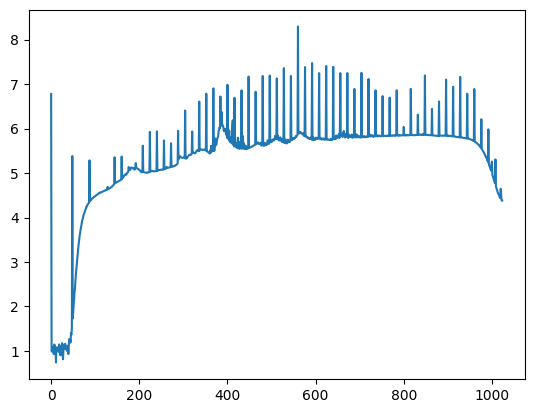

In [20]:
period = 68.78
AZ_STEPS = 72  # with endpoint=True
t_start = 1753038750 + period/2 # s utc
# t_start = times[0] + period/2 # s utc
t_cut = [(1753039060, 1753039181), (1753042808, 1753042834), (1753043111, 1753043119)]  # junk data
i_start = np.searchsorted(times, t_start)
t_stop = t_start + AZ_STEPS * period
i_stop = np.searchsorted(times, t_stop)
sl = slice(i_start, i_stop)
test_data = data['2'][sl]
_times = times[sl].copy()
_times -= _times[0]
plt.figure()
plt.plot(np.log10(test_data[4000, :]))
plt.show()

In [21]:
def fit_hera_pack(nterms, fc, fhw, weights, x, y): # best fits dpss modes
    A, _ = hf.dspec.dpss_operator(x=x, filter_centers=[fc], filter_half_widths=[fhw], nterms=[nterms])
    coeff = hf.dspec.fit_solution_matrix(weights=weights, design_matrix=A)@y
    hera_model = A@coeff
    return hera_model, coeff
chs = np.arange(16, 1024, 16)

dirac_mask = chs
data_zeros = np.ones_like(test_data[0, :])
data_zeros[dirac_mask] = 0
data_zeros[630:750] = 0


nterms = 10
fwh = .00001
fc = 0
pam_bandpass, pam = fit_hera_pack(nterms, fc, fwh, data_zeros, freqs, (test_data.T))

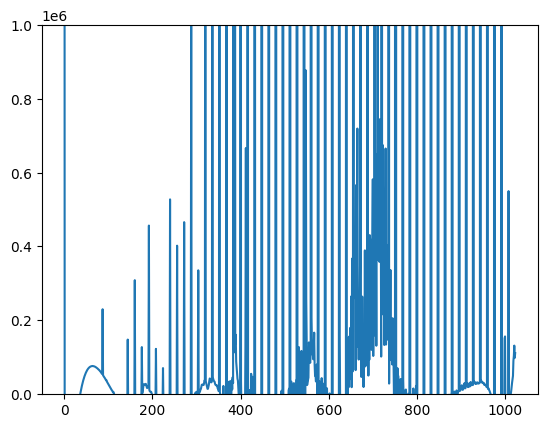

In [22]:
check = 1
plt.figure()
# plt.plot(freqs, (test_data[check, :]))
# plt.plot(freqs, pam_bandpass[:, check])
# plt.plot((test_data[check, :]))
# plt.plot(pam_bandpass[:, check])
# plt.plot(np.log10(test_data[check, :])-pam_bandpass.T[check, :])
plt.plot((test_data[check, :])-pam_bandpass.T[check, :])
# plt.plot(pam)
# plt.plot(freqs[dirac_mask])
plt.ylim(0, 1e6)
plt.axvline(750)
plt.show()

In [8]:
chs = np.arange(16, 1024, 16)
f_ind = 44
# f_ind = 52
# f_ind = 61
# ch = f_ind
k_1 = '2'

# reduced = 10**(np.log10(test_data) - pam_bandpass.T)[:, chs]
# norm = 1 / np.mean(reduced, axis=0, keepdims=True)
# norm[:,:4] = 0
reduced = data[k_1][:, chs]
reduced = data[k_1][:,chs] - 0.5 * (data[k_1][:,chs-1] + data[k_1][:,chs+1])
# valid = np.ones(times.shape, dtype=bool)
# valid = np.where(reduced[:,52] * norm[:,52] < 1e-4, False, ~np.isnan(reduced[:,52]))
# for ti, tj in t_cut:
#     i, j = np.searchsorted(times, ti), np.searchsorted(times, tj)
#     valid[i:j] = False
    
# valid[1:-1] = np.logical_and(valid[1:-1], np.logical_and(valid[:-2], valid[2:]))
# sl = slice(i_start, i_stop)
# _times = times[sl].copy()
# _times -= _times[0]
# # optional for strictly data-driven double-period folding
# #_times_rnd = np.floor(_times / (2 * period))
# #_times_mod = _times - _times_rnd * (2 * period)
# val = valid[sl]

In [9]:
f_ind = 44
# f_ind = 52
# f_ind = 61
ch = f_ind
AZ_STEPS = 72  # with endpoint=True
period = 68.78
#t_start = 1753038750 # s utc
t_start = 1753038750 + period/2 # s utc
# t_start = times[0] + period/2 # s utc
t_cut = [(1753039060, 1753039181), (1753042808, 1753042834), (1753043111, 1753043119)]  # junk data
i_start = np.searchsorted(times, t_start)
norm = 1 / np.mean(reduced[:i_start], axis=0, keepdims=True)
norm[:,:4] = 0
t_stop = t_start + AZ_STEPS * period
i_stop = np.searchsorted(times, t_stop)

valid = np.ones(times.shape, dtype=bool)
valid = np.where(reduced[:,52] * norm[:,52] < 1e-4, False, ~np.isnan(reduced[:,52]))
for ti, tj in t_cut:
    i, j = np.searchsorted(times, ti), np.searchsorted(times, tj)
    valid[i:j] = False
    
valid[1:-1] = np.logical_and(valid[1:-1], np.logical_and(valid[:-2], valid[2:]))
sl = slice(i_start, i_stop)
_times = times[sl].copy()
_times -= _times[0]
# optional for strictly data-driven double-period folding
#_times_rnd = np.floor(_times / (2 * period))
#_times_mod = _times - _times_rnd * (2 * period)
val = valid[sl]
print(freqs[::16][ch])

171.875


In [10]:
import aipy
class BeamFit:
    def __init__(self, times, az_steps=AZ_STEPS, lmax=5):
        self.az_steps = az_steps
        self.times = times
        self.lmax = lmax
        self._el_ax = self._ant_pvec = np.array([1, 0, 0], dtype=dtype_r)
        self._az_ax = np.array([0, 0, -1], dtype=dtype_r)
        self.prms = {}
        self.ant_pvec = self.polresp = self.A_Ylm = self.A = None

    def _set_timing_params(self, prms):
        keys = {'t_off', 'el_off', 't_az_step', 'period'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.az_deg = self.el_deg = self.ant_pvec = self.A_Ylm = self.A = None

    def _set_pol_params(self, prms):
        keys = {'prz', 'px', 'py'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.gnd_pvecs = self.polresp = self.A = None

    def set_params(self, prms):
        self._set_timing_params(prms)
        self._set_pol_params(prms)
        
    def build_az_el(self):
        '''Build az/el coordinates.'''
        if self.ant_pvec is not None:
            return
        az, el, inds = [], [], []
        t_off, el_off, t_az_step, period = self.prms['t_off'], self.prms['el_off'], self.prms['t_az_step'], self.prms['period']
        i = 0
        t_i = self.times[0] + t_off
        for cnt, _az in enumerate(np.linspace(-180, 180, self.az_steps, endpoint=True)):
            t_f = t_i + period
            while i < self.times.size and self.times[i] < t_f - t_az_step:
                az.append(_az)
                if cnt % 2 == 0:
                    el.append(-180 + 360 * (self.times[i] - t_i) / (period - t_az_step))
                else:
                    el.append( 180 - 360 * (self.times[i] - t_i) / (period - t_az_step))
                inds.append(i)
                i += 1
            while i < self.times.size and self.times[i] < t_f:
                az.append(_az + (360 / (self.az_steps - 1)) * (self.times[i] - (t_f - t_az_step))/t_az_step)
                el.append(el[-1])
                inds.append(i)
                i += 1
            t_i = t_f
        self.az_deg = np.array(az)
        self.el_deg = np.array(el) + el_off
        self.inds = np.array(inds)
        rot_az = aipy.coord.rot_m(np.deg2rad(self.az_deg), self._az_ax)
        rot_el = aipy.coord.rot_m(np.deg2rad(self.el_deg), self._el_ax)
        self.ant_pvec = np.einsum('pab,pbc,c->pa', rot_el, rot_az, self._ant_pvec)

    


    
    def build_pol_resp(self):
        self.build_az_el()
        if self.polresp is not None:
            return
        pvec = np.array([[self.prms['px'], 0, 0], [0, self.prms['py'], 0]], dtype=dtype_r)
        rot_m = aipy.coord.rot_m(np.deg2rad(self.prms['prz']), np.array([0, 0, 1])).astype(dtype_r)
        self.gnd_pvecs = np.dot(rot_m, pvec.T).T
        if self.gnd_pvecs.ndim == 1:
            self.gnd_pvecs = self.gnd_pvecs[None, :]
        resp = np.dot(self.ant_pvec, self.gnd_pvecs.T)
        self.polresp = np.sum(np.abs(resp)**2, axis=-1)

    def build_A_Ylm(self):
        self.build_az_el()
        if self.A_Ylm is not None:
            return
        phi = np.deg2rad(self.az_deg)
        theta = np.deg2rad(self.el_deg)
        theta = np.mod(theta, 2*np.pi)
        theta = np.where(theta > np.pi, 2*np.pi - theta, theta)
        phi = np.mod(phi, 2*np.pi)
    
        N = theta.size
        P = (self.lmax + 1)**2
        A = np.empty((N, P), dtype=dtype_r)
    
        # Keep track of which column corresponds to which (l,m,kind)
        # kind ∈ {'m0','c','s'} for m=0, cos-like, sin-like
        self._meta = []
        col = 0
        for ell in range(self.lmax + 1):
            # m = 0 term (purely real)
            Y_l0 = sph_harm(0, ell, phi, theta).real
            #Y_l0 *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
            A[:, col] = Y_l0
            self._meta.append((ell, 0, 'm0'))
            col += 1
    
            # m > 0 terms: sqrt(2)*Re and sqrt(2)*Im
            for m in range(1, ell + 1):
                Y_lm = sph_harm(m, ell, phi, theta)  # complex
                #Y_lm *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
                A[:, col] = SQRT2 * Y_lm.real
                A[:, col+1] = SQRT2 * Y_lm.imag
                self._meta.append((ell, m, 'c'))
                self._meta.append((ell, m, 's'))
                col += 2
    
        assert col == P
        self.A_Ylm = A

    def build_A(self):
        self.build_pol_resp()
        self.build_A_Ylm()
        if self.A is not None:
            return
        self.A = self.A_Ylm * self.polresp[:, None]

    def _realcoeff_to_alm(self, coeff):
        """
        Convert real-basis coeffficients (matching design-matrix columns) into a
        healpy alm array (complex, m>=0). For a real sky, alms obey:
          a_{l,-m} = (-1)^m a_{l m}^*
        We only fill m>=0 as healpy expects.
        """
        alm = np.zeros(Alm.getsize(self.lmax), dtype=dtype_c)
        for k, (ell, m, kind) in enumerate(self._meta):
            if m == 0 and kind == 'm0':
                alm[Alm.getidx(self.lmax, ell, 0)] = coeff[k]
            elif kind in ('c'):
                c = coeff[k]
                s = coeff[k + 1]
                a_lm = (c - 1j * s) / SQRT2
                alm[Alm.getidx(self.lmax, ell, m)] = a_lm
        return alm

    def fit_alms(self, ymeas, w=None, reg=None, rcond=1e-10):
        self.build_A()
    
        # Apply weights (as sqrt weights on rows)
        ymeas = ymeas[self.inds]
        if w is None:
            w = np.ones_like(ymeas)
        else:
            w = w[self.inds]
        sqrtw = np.sqrt(w)
        Aw = self.A * sqrtw[:, None]
        yw = ymeas * sqrtw
    
        # Optional ridge regularization: stack sqrt(reg)*I
        if reg is not None and reg > 0:
            P = self.A.shape[1]
            Aw = np.vstack([Aw, np.sqrt(reg) * np.eye(P)])
            yw = np.concatenate([yw, np.zeros(P)])
    
        coeff = np.linalg.lstsq(Aw[self.inds], yw[self.inds], rcond=rcond)[0]
        yhat = self.A @ coeff
        chisq = np.sum(w * (ymeas[self.inds] - yhat[self.inds])**2)
        alm = self._realcoeff_to_alm(coeff)
        return alm, chisq, yhat

In [23]:
import numpy as np
import aipy

# -------------------------------------------------
# one cell: DPSS fit in linear space, original valid logic preserved
# -------------------------------------------------

def fit_hera_pack(nterms, fc, fhw, weights, x, y):
    A, _ = hf.dspec.dpss_operator(
        x=x,
        filter_centers=[fc],
        filter_half_widths=[fhw],
        nterms=[nterms],
    )
    coeff = hf.dspec.fit_solution_matrix(
        weights=weights,
        design_matrix=A,
    ) @ y
    hera_model = A @ coeff
    return hera_model, coeff

k_1 = '2'
chs = np.arange(16, 1024, 16)
shift = 12
f_ind = 44
ch = f_ind

AZ_STEPS = 72
period = 68.78
t_start = 1753038750 + period / 2
t_stop = t_start + AZ_STEPS * period

t_cut = [
    (1753039060, 1753039181),
    (1753042808, 1753042834),
    (1753043111, 1753043119),
]

t_az_step = 1.7
prms = dict(
    t_az_step=t_az_step,
    t_off=-2.4 + t_az_step / 2,
    el_off=-4.0,
    prz=0.0,
    px=1.0,
    py=0.0,
    period=period,
)

# -------------------------------------------------
# original timing
# -------------------------------------------------

i_start = np.searchsorted(times, t_start)
i_stop = np.searchsorted(times, t_stop)
sl = slice(i_start, i_stop)

_times_abs = times[sl].copy()
_times = _times_abs.copy()
_times -= _times[0]

# full data and sliced data
full_data = data[k_1]
test_data = full_data[sl]

# -------------------------------------------------
# 1) DPSS fit in LINEAR space
# -------------------------------------------------

dirac_mask = chs
data_zeros = np.ones_like(test_data[0, :], dtype=float)
data_zeros[dirac_mask] = 0.0
data_zeros[630:750] = 0.0

nterms = 10
fhw = 1e-5
fc = 0

pam_bandpass, pam = fit_hera_pack(
    nterms,
    fc,
    fhw,
    data_zeros,
    freqs,
    test_data.T,
)

# model on sliced interval, shape (ntime, nfreq)
model_sl = pam_bandpass.T

# science residual in linear difference units
# same units as test_data
reduced_dpss_sl = (test_data - model_sl)[:, chs]

# -------------------------------------------------
# 2) ORIGINAL monitor reduction for valid mask
#    keep this unchanged so timing/indices stay familiar
# -------------------------------------------------

reduced_monitor = full_data[:, chs] - 0.5 * (
    full_data[:, chs - 1] + full_data[:, chs + 1]
)

norm_monitor = 1 / np.mean(reduced_monitor[:i_start], axis=0, keepdims=True)
norm_monitor[:, :4] = 0

valid = np.where(
    reduced_monitor[:, 52] * norm_monitor[:, 52] < 1e-4,
    False,
    ~np.isnan(reduced_monitor[:, 52])
)

for ti, tj in t_cut:
    i, j = np.searchsorted(times, ti), np.searchsorted(times, tj)
    valid[i:j] = False

valid[1:-1] = np.logical_and(valid[1:-1], np.logical_and(valid[:-2], valid[2:]))

val = valid[sl]

# -------------------------------------------------
# 3) normalization for DPSS-reduced science data
# -------------------------------------------------

# robust scale estimated from pre-start data, but using the sliced DPSS-reduced data
# use whatever portion of the slice exists before the modeled scan starts
i0 = 0
if i_start < i_stop:
    i0 = min(max(1, len(reduced_dpss_sl) // 10), len(reduced_dpss_sl))

med = np.nanmedian(reduced_dpss_sl[:i0], axis=0, keepdims=True)
mad = np.nanmedian(np.abs(reduced_dpss_sl[:i0] - med), axis=0, keepdims=True)
norm = 1.0 / (1.4826 * mad)
norm[~np.isfinite(norm)] = 0.0
norm[:, :4] = 0.0

# -------------------------------------------------
# 4) BeamFit on valid times exactly as before
# -------------------------------------------------

fitter = BeamFit(_times[val])
fitter.set_params(prms)
fitter.build_az_el()

az_inds = np.deg2rad(fitter.az_deg)
el_inds = np.deg2rad(fitter.el_deg)

reduced_valid = reduced_dpss_sl[val]
rot = reduced_valid[fitter.inds, shift:]
rot_times = _times[val][fitter.inds]          # relative seconds
rot_times_abs = _times_abs[val][fitter.inds]  # absolute unix times
norm = norm[:, shift:]

print("test_data shape     :", test_data.shape)
print("model_sl shape      :", model_sl.shape)
print("reduced_dpss_sl     :", reduced_dpss_sl.shape)
print("valid in slice      :", np.sum(val), "/", len(val))
print("reduced_valid shape :", reduced_valid.shape)
print("rot shape           :", rot.shape)

test_data shape     : (4607, 1024)
model_sl shape      : (4607, 1024)
reduced_dpss_sl     : (4607, 63)
valid in slice      : 4410 / 4607
reduced_valid shape : (4410, 63)
rot shape           : (4409, 51)


In [12]:
t_az_step = 1.7
prms = dict(
    t_az_step = t_az_step, # XXX degenerate with beam width, need empirical measurement
    t_off = -2.4 + t_az_step/2,
    # t_off = -2.0 + t_az_step/2,
    el_off = -4.0,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # el_off = -8.5,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # az_off is unnecessary given fitting of polarization angle
    prz = 0.0,
    px = 1.0,
    py = 0.0,
    period = period,
)

# # force a rebuild
# fitter.ant_pvec = None
# fitter.az_deg = None
# fitter.el_deg = None
# fitter.A_Ylm = None
# fitter.A = None
# fitter.build_az_el()

fitter = BeamFit(_times[val])
fitter.set_params(prms)
fitter.build_az_el()
az_inds = np.deg2rad(fitter.az_deg[fitter.inds])
el_inds = np.deg2rad(fitter.el_deg[fitter.inds])

In [13]:

def fit_hera_pack(nterms, fc, fhw, weights, x, y): # best fits dpss modes
    A, _ = hf.dspec.dpss_operator(x=x, filter_centers=[fc], filter_half_widths=[fhw], nterms=[nterms])
    coeff = hf.dspec.fit_solution_matrix(weights=weights, design_matrix=A)@y
    hera_model = A@coeff
    return hera_model, coeff
chs = np.arange(16, 1024, 16)

test_data = data['2'][sl]
dirac_mask = chs
data_zeros = np.ones_like(test_data[0, :])
data_zeros[dirac_mask] = 0


nterms = 20
fwh = .00001
fc = 0
pam_bandpass, pam = fit_hera_pack(nterms, fc, fwh, data_zeros, freqs, np.log10(test_data.T))
reduced = 10**(np.log10(test_data) - pam_bandpass.T)[:, chs]

/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_88238/399338117.py:17: RuntimeWarning: divide by zero encountered in log10
  pam_bandpass, pam = fit_hera_pack(nterms, fc, fwh, data_zeros, freqs, np.log10(test_data.T))
/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_88238/399338117.py:17: RuntimeWarning: invalid value encountered in log10
  pam_bandpass, pam = fit_hera_pack(nterms, fc, fwh, data_zeros, freqs, np.log10(test_data.T))
/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_88238/399338117.py:3: RuntimeWarning: invalid value encountered in matmul
  coeff = hf.dspec.fit_solution_matrix(weights=weights, design_matrix=A)@y
/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_88238/399338117.py:18: RuntimeWarning: divide by zero encountered in log10
  reduced = 10**(np.log10(test_data) - pam_bandpass.T)[:, chs]
/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_88238/399338117.py:18: RuntimeWarning: invalid value encountered in log10
  red

In [14]:
reduced.shape, el_inds.shape

((4607, 63), (4409,))

In [15]:
shift = 12
rot = reduced[:, shift:][sl][val][fitter.inds] #* norm[:, ch]
norm = norm[:, shift:]
outfile = 'figures/'
print(rot.shape, norm.shape)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 0 but corresponding boolean dimension is 4607

In [16]:
rot_times = times[sl][val][fitter.inds]
rot_freq = freqs[chs[shift:]]
rot_freq.shape

(51,)

## Waterfall During Rotations

(array([], dtype=int64),)


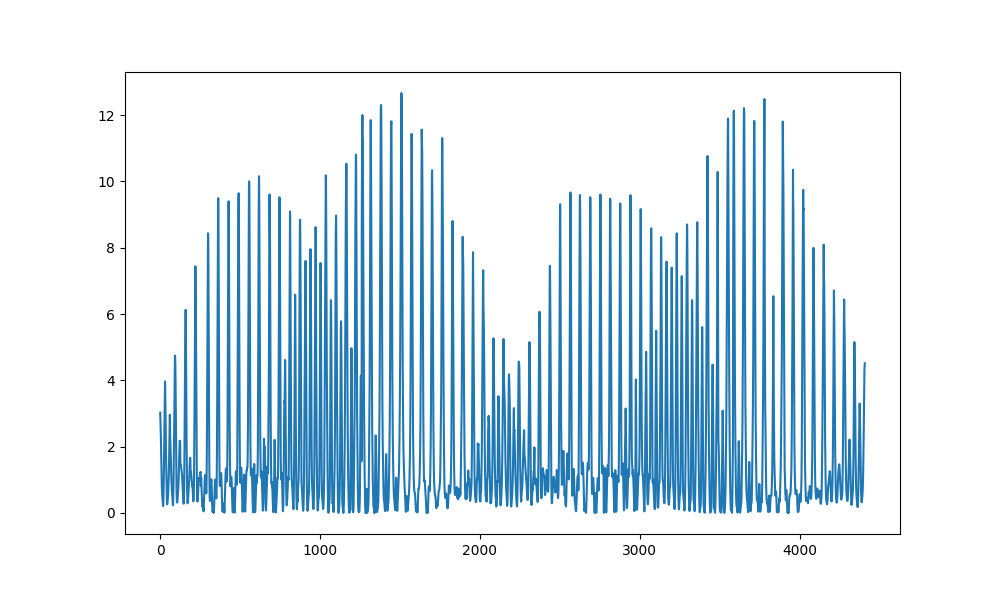

In [34]:
print(np.where(rot_data[:, 35] < 0))
plt.figure(figsize=(10, 6))
plt.plot(rot_data[:, 35])
plt.show()

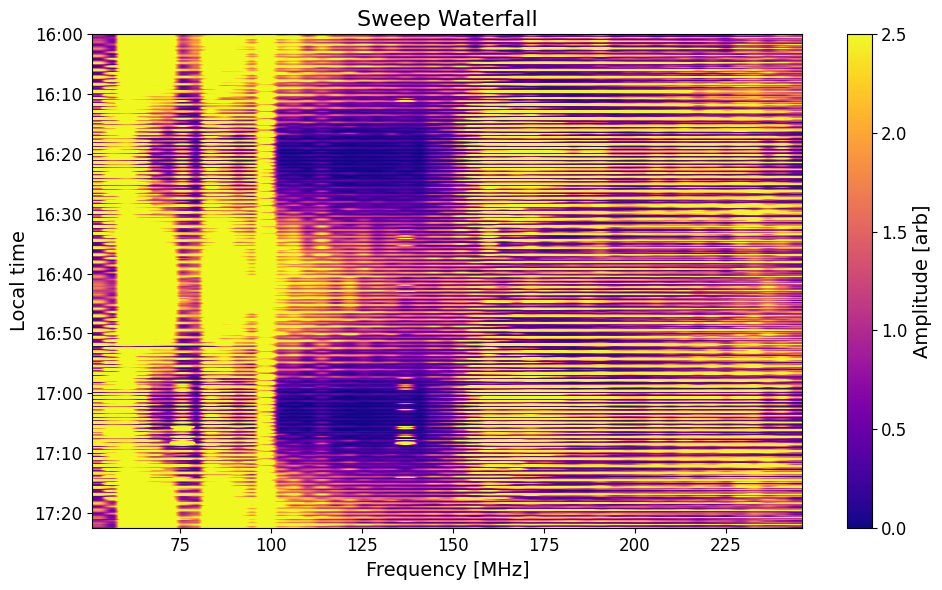

In [24]:
import matplotlib.dates as mdates

local_rot_times = [datetime.fromtimestamp(t) for t in rot_times]

rot_data = rot.real*norm
rot_data[np.where(rot_data<0)] = 0
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    rot_data,
    aspect='auto',
    origin='lower',
    extent=[rot_freq.min(), rot_freq.max(), mdates.date2num(local_rot_times[-1]), mdates.date2num(local_rot_times[0])],
    vmin=0, vmax=2.5, cmap='plasma'
)

ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("Local time", fontsize=14)
ax.set_title("Sweep Waterfall", fontsize=16)
ax.tick_params(axis='both', labelsize=12)

# format the y-axis as dates/rot_times
ax.yaxis_date()
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# fig.colorbar(im, ax=ax, label="Power")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Amplitude [arb]", fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
# plt.savefig('/Users/dominiv/sfsu/thesis/figures/waterfall.pdf')
# plt.savefig('/Users/dominiv/sfsu/cose2026/figures/waterfall.pdf')
plt.show()

/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_65029/1943414821.py:2: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(rot[:, 32].real*norm[:, 32]))


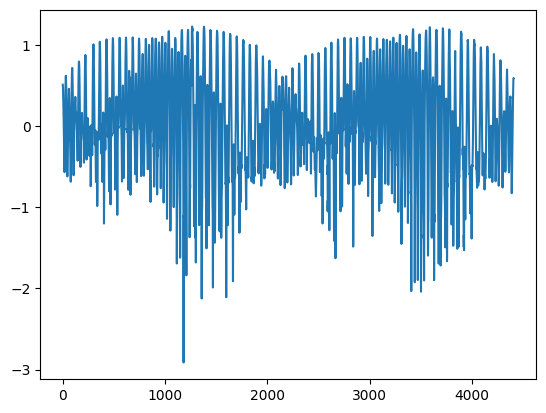

In [79]:
plt.figure()
plt.plot(np.log10(rot[:, 32].real*norm[:, 32]))
# plt.plot((rot[:, 32].real*norm[:, 32]))
plt.show()

## El and Az Mapping of One Frequency

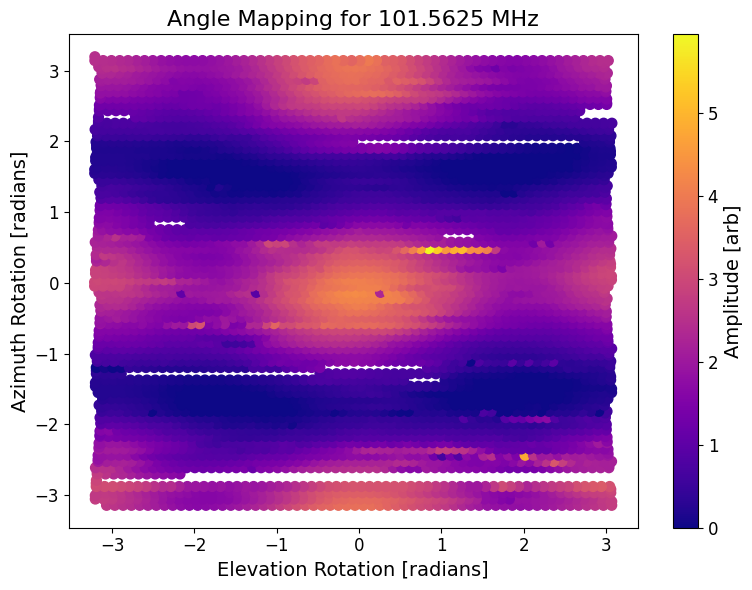

In [109]:
# fig_ind = 35
# fig_ind = 38
fig_ind = 13
fig_freq = rot_freq[fig_ind]

rot_data = rot[:, fig_ind].real*norm[:, fig_ind]
rot_data[np.where(rot_data<0)] = 0
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.scatter(el_inds, az_inds,
    c=rot_data,
    vmin=None, vmax=None, s=50, cmap='plasma'
)

ax.set_xlabel("Elevation Rotation [radians]", fontsize=14)
ax.set_ylabel("Azimuth Rotation [radians]", fontsize=14)
ax.set_title(f'Angle Mapping for {fig_freq} MHz', fontsize=16)
ax.tick_params(axis='both', labelsize=12)

# format the y-axis as dates/rot_times
# ax.yaxis_date()
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# fig.colorbar(im, ax=ax, label="Power")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Amplitude [arb]", fontsize=14)
cbar.ax.tick_params(labelsize=12)
# plt.savefig('/Users/dominiv/sfsu/thesis/figures/power_scatter.pdf')
# plt.savefig('/Users/dominiv/sfsu/cose2026/figures/power_scatter.pdf')
plt.tight_layout()
plt.show()

In [62]:
np.where(rot[:, fig_ind].real * norm[:, fig_ind] < 0)

(array([ 846,  853,  857,  858,  869,  870,  884,  885,  886,  887,  888,
         889,  890,  891,  892,  893,  894,  900,  919,  920,  921,  922,
         923,  924,  925,  926,  927,  928,  929,  930,  931,  952,  953,
         954,  955,  956,  957,  958,  959,  960,  963,  980,  981,  982,
         983,  984,  985,  986,  987,  988,  989,  990,  991, 1013, 1014,
        1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1048, 1049,
        1050, 1051, 1052, 1053, 1054, 1055, 1056, 1080, 1081, 1082, 1083,
        1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1107, 1108,
        1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1146, 1147,
        1148, 1149, 1150, 1151, 1152, 1207, 1208, 1209, 1210, 1211, 1212,
        1213, 1214, 1215, 1216, 1217, 1234, 1235, 1266, 1268, 1335, 3089,
        3090, 3144, 3145, 3146, 3147, 3148, 3149, 3183, 3184, 3185, 3186,
        3187, 3188, 3189, 3190, 3191, 3212, 3213, 3216, 3217, 3218, 3219,
        3240, 3241, 3242, 3243, 3244, 

## Bowtie S11, bot sure if box is present

In [98]:
s11 = np.loadtxt('/Users/dominiv/research/data/original_s11/Copy of S_Parameter_dB.csv', delimiter=',', skiprows=1)

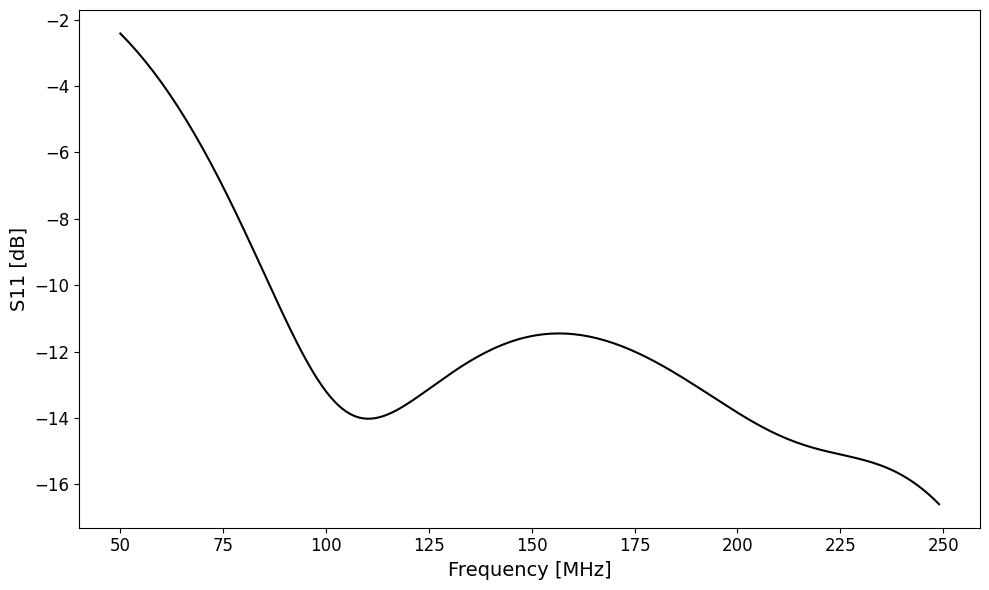

In [114]:
# plt.figure()
# plt.plot(s11[:200, 0], s11[:200, 1])
# # plt.xlim(50, 250)
# # plt.ylim(-20, -2)
# plt.show()
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.plot(s11[:200, 0], s11[:200, 1], color='black')

ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("S11 [dB]", fontsize=14)
# ax.set_title(f'Angle Mapping for {fig_freq} MHz', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

# format the y-axis as dates/rot_times
# ax.yaxis_date()
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# fig.colorbar(im, ax=ax, label="Power")
# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label("Power", fontsize=14)
# cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

## HFSS Simulated Beam Maps

In [117]:
beam_maps_th = np.load('/Users/dominiv/eigsep/data/beam_th.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
beam_maps_ph = np.load('/Users/dominiv/eigsep/data/beam_ph.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
gain_maps = beam_maps_th + beam_maps_ph

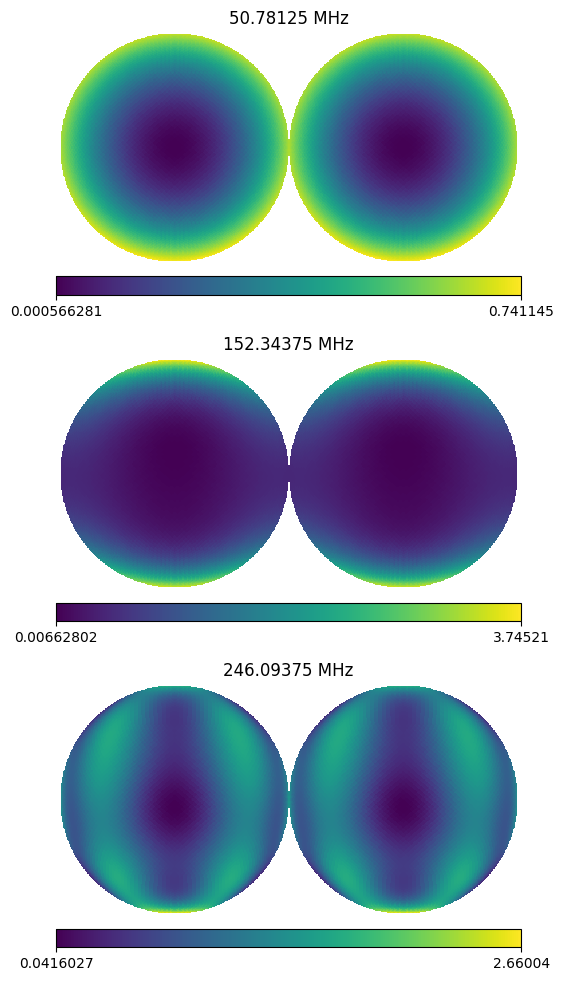

In [137]:


# hp.orthview(gain_maps[0], title=f'{rot_freq[0]} MHz')
# hp.orthview(gain_maps[23], title=f'{rot_freq[23]} MHz')
# hp.orthview(gain_maps[-1], title=f'{rot_freq[-1]} MHz')

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

plt.sca(axs[0])
hp.orthview(
    gain_maps[0],
    title=f'{rot_freq[0]} MHz',
    hold=True,
    cbar=True
)

plt.sca(axs[1])
hp.orthview(
    gain_maps[26],
    title=f'{rot_freq[26]} MHz',
    hold=True,
    cbar=True
)

plt.sca(axs[2])
hp.orthview(
    gain_maps[-1],
    title=f'{rot_freq[-1]} MHz',
    hold=True,
    cbar=True
)

# plt.tight_layout()
plt.show()

## Dirac Comb in Code

In [138]:
waveform = np.load('/Users/dominiv/eigsep/DAC/notebooks/transmitter.npz')

In [147]:
freqs.shape

(1024,)

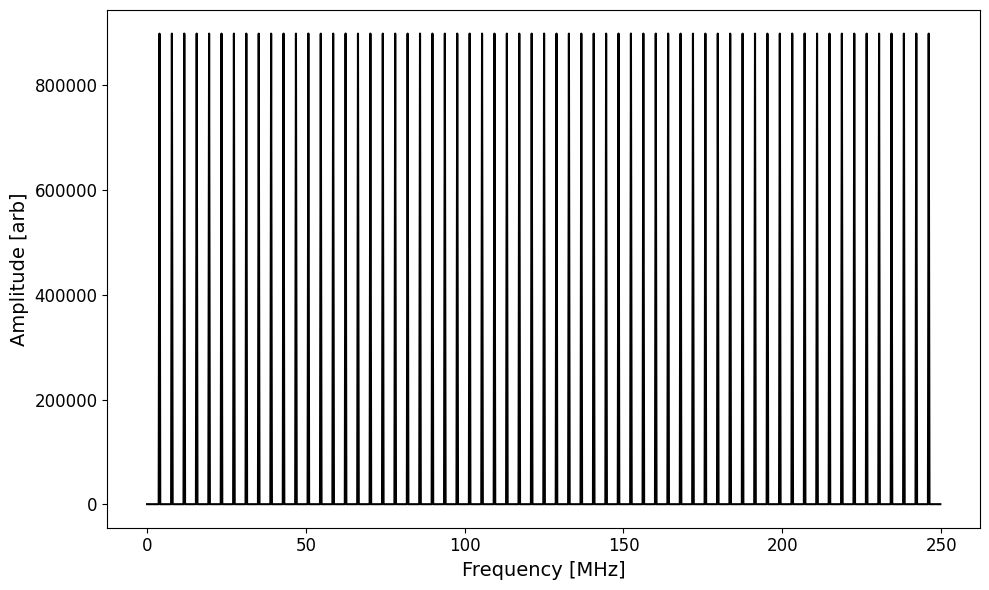

In [181]:
fft_wave = np.abs(np.fft.fft(waveform['data']))

# plt.figure()
# plt.plot((freqs), np.fft.fftshift(fft_wave)[2048:2048+1024])
# plt.
# plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.plot(freqs, np.fft.fftshift(fft_wave)[2048:2048+1024], color='black')
ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("Amplitude [arb]", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
# plt.savefig('/Users/dominiv/sfsu/thesis/figures/dirac_comb.pdf')
plt.show()

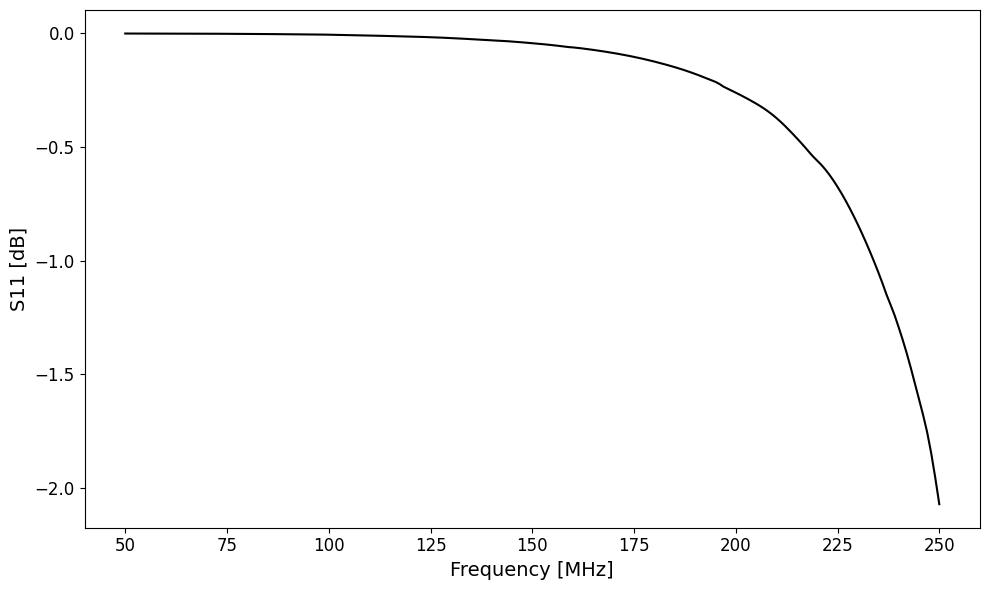

In [180]:
s11_transmitter = np.loadtxt(   '/Users/dominiv/research/data/S11_Transmitter.csv', delimiter=',', skiprows=1)
inc = 201
ang = 361

phis =   np.deg2rad(s11_transmitter[:, 0][::inc])
thetas = np.deg2rad(s11_transmitter[:, 1][::inc])
freqs_hfss = s11_transmitter[:inc, 2]

def db_lin(db):
    # return 10**(db/10)
    return db

s11_t = db_lin(s11_transmitter[:, 3])
s11_t = s11_t.reshape(ang, inc)


fig, ax = plt.subplots(figsize=(10, 6))
im = ax.plot(freqs_hfss, s11_t[9, :], color='black')
ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("S11 [dB]", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig('/Users/dominiv/sfsu/thesis/figures/s11_trans.pdf')
plt.show()

In [110]:
import eigsep_observing as eo

In [113]:
s11_data = eo.io.read_s11_file('/Users/dominiv/eigsep/data/s11_data/ants11_20250719_102527.h5')

In [141]:
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import re

import eigsep_observing as eo

S11_RE = re.compile(r".*s11_(\d{8})_(\d{6})\.h5$")


def filename_to_unix(path, tz=timezone.utc):
    """
    Convert a filename like ants11_20250719_102527.h5 to Unix time.

    Assumes the timestamp in the filename is in `tz`.
    """
    m = S11_RE.match(path.name)
    if m is None:
        return None

    date_str, time_str = m.groups()
    dt = datetime.strptime(f"{date_str}_{time_str}", "%Y%m%d_%H%M%S").replace(tzinfo=tz)
    return dt.timestamp()


def maybe_stack(arr_list):
    """
    Stack arrays if they all have the same shape; otherwise return the list.
    """
    if not arr_list:
        return np.array([])

    arr_list = [np.asarray(x) for x in arr_list]
    shapes = {a.shape for a in arr_list}
    return np.stack(arr_list, axis=0) if len(shapes) == 1 else arr_list


def load_s11_with_cal_in_unix_range(folder, tmin, tmax, tz=timezone.utc):
    """
    Find S11 files whose filename timestamps fall in [tmin, tmax],
    then load and separate main data from calibration data.

    Returns a dict with:
      times, files,
      ant, noise, load,          # from data
      cal_open, cal_short, cal_load   # from cal_data
    """
    folder = Path(folder)

    matched = []
    for path in sorted(folder.glob("*s11_*.h5")):
        ts = filename_to_unix(path, tz=tz)
        if ts is None:
            continue
        if tmin <= ts <= tmax:
            matched.append((ts, path))

    times = []
    files = []

    ant_list = []
    noise_list = []
    load_list = []

    cal_open_list = []
    cal_short_list = []
    cal_load_list = []

    for ts, path in matched:
        data, cal_data, header, metadata = eo.io.read_s11_file(path)

        times.append(ts)
        files.append(str(path))

        # main data
        if "ant" in data:
            ant_list.append(data["ant"])
        if "noise" in data:
            noise_list.append(data["noise"])
        if "load" in data:
            load_list.append(data["load"])

        # calibration data
        if "open" in cal_data:
            cal_open_list.append(cal_data["open"])
        if "short" in cal_data:
            cal_short_list.append(cal_data["short"])
        if "load" in cal_data:
            cal_load_list.append(cal_data["load"])

    return {
        "times": np.array(times),
        "files": files,
        "ant": maybe_stack(ant_list),
        "noise": maybe_stack(noise_list),
        "load": maybe_stack(load_list),
        "cal_open": maybe_stack(cal_open_list),
        "cal_short": maybe_stack(cal_short_list),
        "cal_load": maybe_stack(cal_load_list),
    }

tmin = 1753038784.7891824
tmax = 1753043734.738991

result = load_s11_with_cal_in_unix_range(
    "/Users/dominiv/eigsep/data/s11_data",
    tmin,
    tmax,
)

ant = result["ant"]
noise = result["noise"]
load = result["load"]

cal_open = result["cal_open"]
cal_short = result["cal_short"]
cal_load = result["cal_load"]

print("matched files:", len(result["files"]))
print("main keys:")
print("  ant:", getattr(ant, "shape", f"list[{len(ant)}]"))
print("  noise:", getattr(noise, "shape", f"list[{len(noise)}]"))
print("  load:", getattr(load, "shape", f"list[{len(load)}]"))

print("cal keys:")
print("  cal_open:", getattr(cal_open, "shape", f"list[{len(cal_open)}]"))
print("  cal_short:", getattr(cal_short, "shape", f"list[{len(cal_short)}]"))
print("  cal_load:", getattr(cal_load, "shape", f"list[{len(cal_load)}]"))

matched files: 2
main keys:
  ant: (1, 1000)
  noise: (1, 1000)
  load: (1, 1000)
cal keys:
  cal_open: (0,)
  cal_short: (0,)
  cal_load: (0,)


In [166]:
s11_freqs = np.asarray(s11_data[2]['freqs']) / 1e6
result['files']

['/Users/dominiv/eigsep/data/s11_data/ants11_20250720_193911.h5',
 '/Users/dominiv/eigsep/data/s11_data/recs11_20250720_194000.h5']

In [192]:
s11_test = eo.io.read_s11_file(result['files'][0])
def lin2dB(data):
    return 20*np.log10(np.abs(data))

VNAO = s11_test[1]['VNAO']
VNAS = s11_test[1]['VNAS']
VNAL = s11_test[1]['VNAL']
ant  = s11_test[0]['ant']

In [196]:
s11_test_1 = eo.io.read_s11_file(result['files'][1])

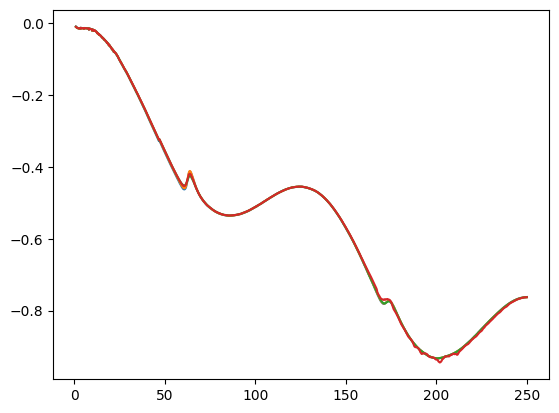

In [198]:
plt.figure()
plt.plot(s11_freqs, lin2dB(VNAO))
plt.plot(s11_freqs, lin2dB(VNAS))
plt.plot(s11_freqs, lin2dB(VNAL))
plt.plot(s11_freqs, lin2dB(ant ))
# plt.plot(s11_freqs, lin2dB(s11_test_1[0]['rec']))
plt.show()

In [334]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import numpy as np

from eigsep_observing.io import read_hdf5


def extract_corrs_in_unix_range(
    data_dir: str | Path,
    t_start: float,
    t_stop: float,
    verbose: bool = True,
) -> dict[str, Any]:
    """
    Extract all correlations (auto + cross) from all readable corr_*.h5 files
    whose samples overlap [t_start, t_stop] in Unix seconds.

    This version does NOT trust filename timestamps.
    Bad/corrupt files are skipped.

    Returns
    -------
    dict with:
        times      : (N,) float array of Unix timestamps
        data       : {corr_key: (N, ... ) array}
        metadata   : list of per-file metadata dicts
        files      : list of matched good file paths
        bad_files  : list of {"file": ..., "error": ...}
    """
    data_dir = Path(data_dir)

    if t_stop < t_start:
        raise ValueError("t_stop must be >= t_start")

    all_files = sorted(data_dir.glob("corr_*.h5"))

    if verbose:
        print(f"Found {len(all_files)} corr files")

    collected_times = []
    collected_data: dict[str, list[np.ndarray]] = {}
    matched_metadata = []
    matched_files = []
    bad_files = []

    for path in all_files:
        try:
            data, header, metadata = read_hdf5(path)
        except Exception as e:
            bad_files.append({"file": str(path), "error": f"{type(e).__name__}: {e}"})
            if verbose:
                print(f"Skipping bad file: {path.name}")
                print(f"  {type(e).__name__}: {e}")
            continue

        if "times" not in header:
            bad_files.append({"file": str(path), "error": "Missing header['times']"})
            if verbose:
                print(f"Skipping file with no header['times']: {path.name}")
            continue

        try:
            times = np.asarray(header["times"], dtype=float)
        except Exception as e:
            bad_files.append(
                {"file": str(path), "error": f"Bad header['times']: {type(e).__name__}: {e}"}
            )
            if verbose:
                print(f"Skipping file with unreadable header['times']: {path.name}")
                print(f"  {type(e).__name__}: {e}")
            continue

        mask = (times >= t_start) & (times <= t_stop)
        if not np.any(mask):
            continue

        file_data = {}
        for corr_key, arr in data.items():
            try:
                arr = np.asarray(arr)
                if arr.shape[0] != times.shape[0]:
                    if verbose:
                        print(
                            f"Skipping dataset '{corr_key}' in {path.name}: "
                            f"{arr.shape[0]} rows vs {times.shape[0]} timestamps"
                        )
                    continue
                file_data[corr_key] = arr[mask]
            except Exception as e:
                if verbose:
                    print(f"Skipping dataset '{corr_key}' in {path.name}: {type(e).__name__}: {e}")

        if not file_data:
            continue

        matched_files.append(str(path))
        collected_times.append(times[mask])
        matched_metadata.append(
            {
                "file": str(path),
                "selected_indices": np.nonzero(mask)[0],
                "metadata": metadata,
            }
        )

        for corr_key, arr in file_data.items():
            collected_data.setdefault(corr_key, []).append(arr)

        if verbose:
            print(f"Used {path.name}: selected {mask.sum()} rows")

    if not collected_times:
        return {
            "times": np.array([], dtype=float),
            "data": {},
            "metadata": [],
            "files": [],
            "bad_files": bad_files,
        }

    out = {
        "times": np.concatenate(collected_times, axis=0),
        "data": {
            corr_key: np.concatenate(chunks, axis=0)
            for corr_key, chunks in collected_data.items()
        },
        "metadata": matched_metadata,
        "files": matched_files,
        "bad_files": bad_files,
    }

    order = np.argsort(out["times"])
    out["times"] = out["times"][order]
    for corr_key in out["data"]:
        out["data"][corr_key] = out["data"][corr_key][order]

    return out


# Your interval
bounds = 120*5
result = extract_corrs_in_unix_range(
    data_dir="/Users/dominiv/eigsep/data/corr_data/",
    t_start=1753038784.39 - bounds,
    t_stop=1753043736.5500002 + bounds,
    verbose=True,
)

print("\nSummary")
print("-------")
print("Good files used:", len(result["files"]))
print("Bad files skipped:", len(result["bad_files"]))
print("Selected times:", result["times"].shape)

print("\nCorrelation keys:")
print(sorted(result["data"].keys()))

for k in sorted(result["data"]):
    print(f"{k}: {result['data'][k].shape}")

# Uncomment to inspect bad files:
# for x in result["bad_files"]:
#     print(x)

Found 873 corr files
Skipping bad file: corr_20250715_094242.h5
  JSONDecodeError: Expecting value: line 1 column 1 (char 0)
Skipping bad file: corr_20250717_121804.h5
  OSError: Unable to synchronously open file (bad object header version number)
Skipping bad file: corr_20250718_091358.h5
  OSError: Unable to synchronously open file (bad object header version number)
Used corr_20250720_120434.h5: selected 85 rows
Used corr_20250720_120851.h5: selected 240 rows
Used corr_20250720_121310.h5: selected 240 rows
Used corr_20250720_121728.h5: selected 240 rows
Used corr_20250720_122147.h5: selected 240 rows
Used corr_20250720_122604.h5: selected 240 rows
Used corr_20250720_123022.h5: selected 240 rows
Used corr_20250720_123440.h5: selected 240 rows
Used corr_20250720_123858.h5: selected 240 rows
Used corr_20250720_124316.h5: selected 240 rows
Used corr_20250720_124734.h5: selected 240 rows
Used corr_20250720_125152.h5: selected 240 rows
Used corr_20250720_125609.h5: selected 240 rows
Used c

In [335]:
# box_ant = result['data']['2'][:, chs][val][fitter.inds][:, shift:]
# viv_ant = result['data']['4'][:, chs][val][fitter.inds][:, shift:]
# cross = result['data']['24'][:, chs][val][fitter.inds][:, shift:]
box_ant = result['data']['2'][:, chs][:, shift:]
viv_ant = result['data']['4'][:, chs][:, shift:]
cross = result['data']['24'][:, chs][:, shift:]
# test_rot = data['2'][sl][:, chs][val][fitter.inds][:, shift:]
# test_ant.shape, test_rot.shape

/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_65029/1982560659.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(box_ant), aspect='auto')


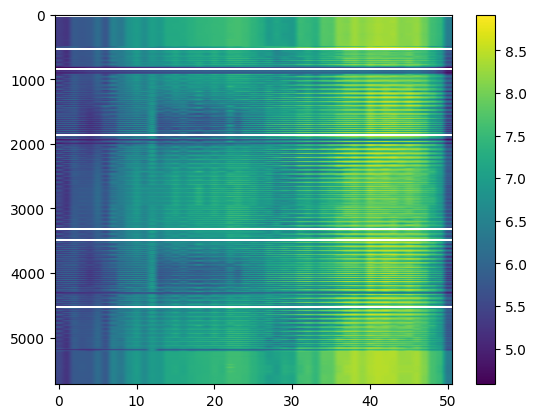

/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_65029/1982560659.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(viv_ant), aspect='auto')


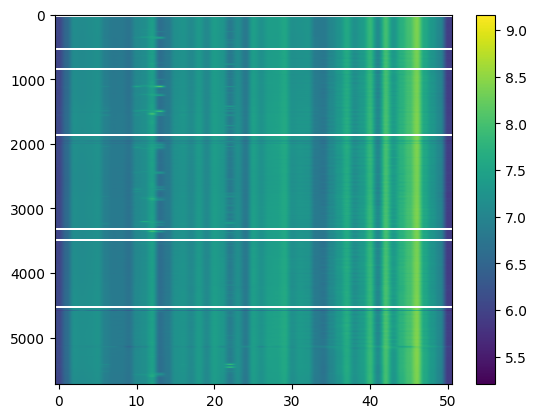

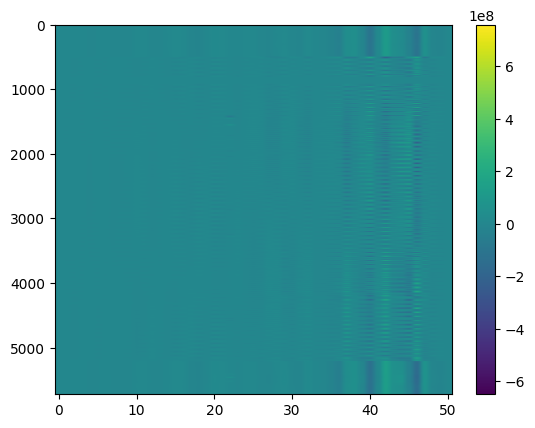

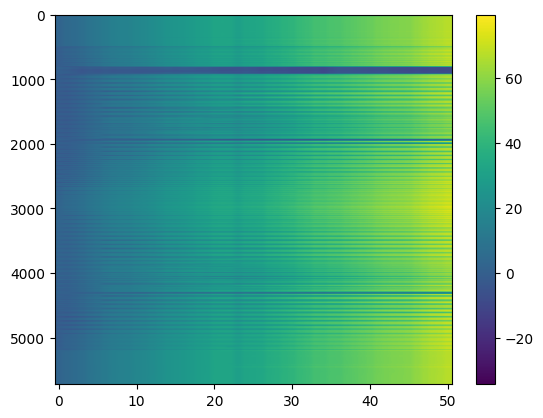

In [336]:
plt.figure()
plt.imshow(np.log10(box_ant), aspect='auto')
plt.colorbar()
plt.show()
plt.figure()
plt.imshow(np.log10(viv_ant), aspect='auto')
plt.colorbar()
plt.show()

plt.figure()
plt.imshow((cross.real), aspect='auto')
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(np.unwrap(np.angle(cross)), aspect='auto')
plt.colorbar()
plt.show()

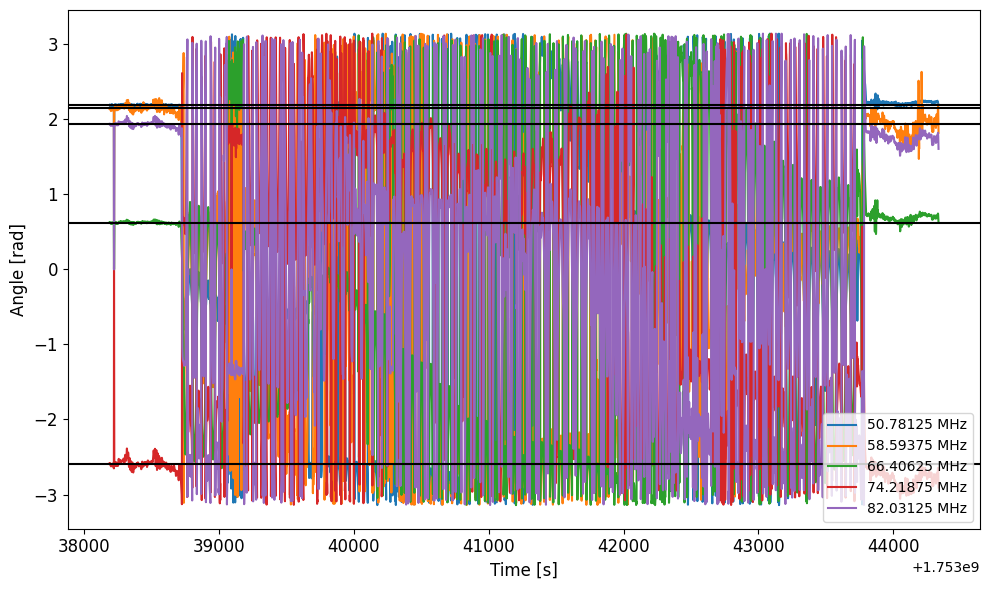

In [374]:
plt.figure(figsize=(10, 6))
# plt.plot(cross[:, 30].real)
# plt.plot(cross[:, 30].imag)
# plt.plot(result['times'], (np.angle(cross[:, 0])), color='black', label=f'{rot_freq[0]} MHz')
# plt.axhline(np.angle(cross[:, 0])[0], color='red')
for i in range(5):
    plt.plot(result['times'], (np.angle(cross[:, ::12][:, i])), label=f'{rot_freq[::2][i]} MHz')
    plt.axhline(np.angle(cross[:, ::12][:, i])[0], color='black', zorder=5)
plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Angle [rad]', fontsize=12)
plt.legend()
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

In [312]:
cross.shape

(4409, 51)

In [375]:
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np

from eigsep_observing.io import read_s11_file


def _to_unix_scalar(x):
    """Best-effort conversion of a scalar/array-like timestamp to a Unix float."""
    if x is None:
        return None

    # numpy arrays / lists
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.asarray(x)
        if arr.size == 0:
            return None
        x = arr.ravel()[0]

    # numpy scalar -> python scalar
    if isinstance(x, np.generic):
        x = x.item()

    # already numeric
    if isinstance(x, (int, float)):
        return float(x)

    # datetime
    if isinstance(x, datetime):
        if x.tzinfo is None:
            x = x.replace(tzinfo=timezone.utc)
        return float(x.timestamp())

    # ISO string
    if isinstance(x, str):
        s = x.strip()
        try:
            # handle trailing Z
            if s.endswith("Z"):
                s = s[:-1] + "+00:00"
            dt = datetime.fromisoformat(s)
            if dt.tzinfo is None:
                dt = dt.replace(tzinfo=timezone.utc)
            return float(dt.timestamp())
        except Exception:
            pass

        # numeric string
        try:
            return float(s)
        except Exception:
            return None

    return None


def _extract_file_time_unix(path, header, metadata):
    """
    Try to recover the S11 measurement time from header/metadata.
    Falls back to filename timestamp if needed.
    """
    # Likely places a measurement timestamp might live
    candidates = [
        header.get("times"),
        metadata.get("times"),
        header.get("time"),
        metadata.get("time"),
        header.get("timestamp"),
        metadata.get("timestamp"),
        header.get("utc"),
        metadata.get("utc"),
        header.get("datetime"),
        metadata.get("datetime"),
        header.get("date"),
        metadata.get("date"),
        metadata.get("start_time"),
        header.get("start_time"),
    ]

    for c in candidates:
        t = _to_unix_scalar(c)
        if t is not None:
            return t, "header/metadata"

    # Fallback: parse filename like ants11_20250719_102527.h5 / recs11_...
    stem = path.stem
    for prefix in ("ants11_", "recs11_"):
        if stem.startswith(prefix):
            ts_part = stem[len(prefix):].split("-", 1)[0]  # allow suffix like -1
            try:
                dt = datetime.strptime(ts_part, "%Y%m%d_%H%M%S").replace(tzinfo=timezone.utc)
                return float(dt.timestamp()), "filename"
            except Exception:
                pass

    return None, None


def extract_s11_in_unix_range(
    data_dir: str | Path,
    t_start: float,
    t_stop: float,
    which: str = "both",   # "ant", "rec", or "both"
    include_cal: bool = True,
    verbose: bool = True,
) -> dict[str, Any]:
    """
    Extract S11 files in a Unix time window.

    Parameters
    ----------
    data_dir : str or Path
        Folder containing ants11_*.h5 and/or recs11_*.h5.
    t_start, t_stop : float
        Unix start/stop times in seconds.
    which : {"ant", "rec", "both"}
        Which file family to search.
    include_cal : bool
        Keep calibration traces returned by read_s11_file().
    verbose : bool
        Print skipped/used files.

    Returns
    -------
    dict with keys:
        files       : list of matched file paths
        file_times  : np.ndarray of matched file times (Unix seconds)
        kind        : list of "ant" / "rec"
        data        : list of per-file data dicts
        cal_data    : list of per-file cal dicts
        headers     : list of per-file headers
        metadata    : list of per-file metadata dicts
        bad_files   : list of {"file", "error"}
    """
    data_dir = Path(data_dir)

    if t_stop < t_start:
        raise ValueError("t_stop must be >= t_start")
    if which not in {"ant", "rec", "both"}:
        raise ValueError("which must be 'ant', 'rec', or 'both'")

    patterns = []
    if which in {"ant", "both"}:
        patterns.append("ants11_*.h5")
    if which in {"rec", "both"}:
        patterns.append("recs11_*.h5")

    all_files = []
    for pat in patterns:
        all_files.extend(sorted(data_dir.glob(pat)))
    all_files = sorted(all_files)

    out = {
        "files": [],
        "file_times": [],
        "kind": [],
        "data": [],
        "cal_data": [],
        "headers": [],
        "metadata": [],
        "bad_files": [],
    }

    for path in all_files:
        try:
            data, cal_data, header, metadata = read_s11_file(path)
        except Exception as e:
            out["bad_files"].append({"file": str(path), "error": f"{type(e).__name__}: {e}"})
            if verbose:
                print(f"Skipping bad S11 file: {path.name}")
                print(f"  {type(e).__name__}: {e}")
            continue

        t_file, source = _extract_file_time_unix(path, header, metadata)
        if t_file is None:
            out["bad_files"].append({"file": str(path), "error": "Could not determine file time"})
            if verbose:
                print(f"Skipping {path.name}: could not determine measurement time")
            continue

        if not (t_start <= t_file <= t_stop):
            continue

        kind = "ant" if path.name.startswith("ants11_") else "rec"

        out["files"].append(str(path))
        out["file_times"].append(t_file)
        out["kind"].append(kind)
        out["data"].append(data)
        out["cal_data"].append(cal_data if include_cal else {})
        out["headers"].append(header)
        out["metadata"].append(metadata)

        if verbose:
            dt = datetime.fromtimestamp(t_file, tz=timezone.utc)
            print(f"Using {path.name}  [{kind}]  time={dt.isoformat()}  source={source}")

    out["file_times"] = np.asarray(out["file_times"], dtype=float)

    if len(out["file_times"]) > 0:
        order = np.argsort(out["file_times"])
        for key in ("file_times",):
            out[key] = out[key][order]
        for key in ("files", "kind", "data", "cal_data", "headers", "metadata"):
            out[key] = [out[key][i] for i in order]

    return out


# Example: same time window as before
s11_result = extract_s11_in_unix_range(
    data_dir="/Users/dominiv/eigsep/data/s11_data/",
    t_start=1753038784.39,
    t_stop=1753043736.5500002,
    which="both",      # or "ant" / "rec"
    include_cal=True,
    verbose=True,
)

print("\nMatched S11 files:", len(s11_result["files"]))
for f, t, kind in zip(s11_result["files"], s11_result["file_times"], s11_result["kind"]):
    print(kind, t, f)

Using ants11_20250720_193911.h5  [ant]  time=2025-07-20T19:39:11+00:00  source=filename
Using recs11_20250720_194000.h5  [rec]  time=2025-07-20T19:40:00+00:00  source=filename

Matched S11 files: 2
ant 1753040351.0 /Users/dominiv/eigsep/data/s11_data/ants11_20250720_193911.h5
rec 1753040400.0 /Users/dominiv/eigsep/data/s11_data/recs11_20250720_194000.h5


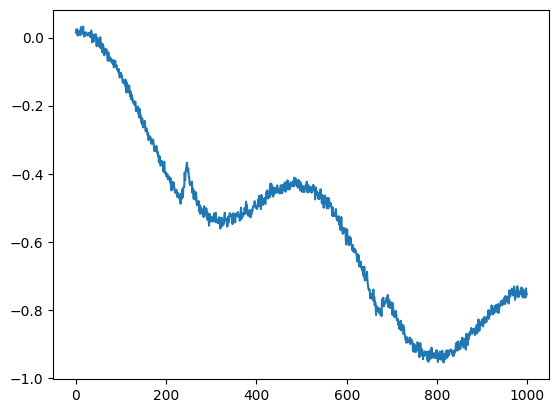

In [384]:
plt.figure()
plt.plot(lin2dB(s11_result['data'][1]['rec']))
plt.show()

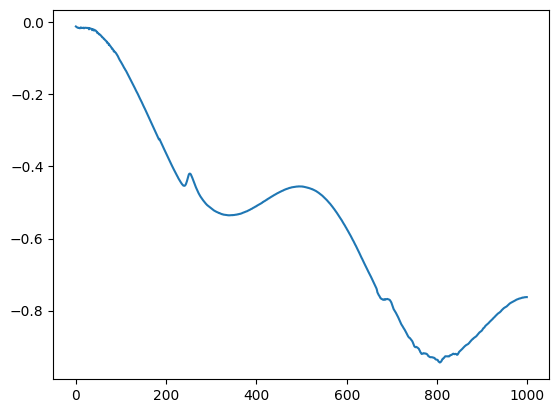

In [391]:
plt.figure()
plt.plot(lin2dB(s11_result['data'][0]['ant']))
plt.show()

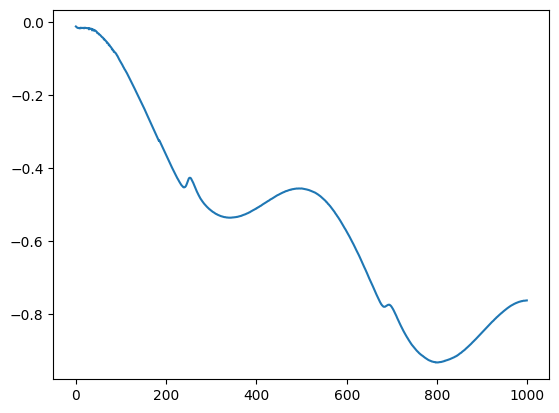

In [396]:
plt.figure()
plt.plot(lin2dB(s11_result['cal_data'][0]['VNAL']))
plt.show()

In [400]:
from eigsep_data import S11

In [465]:
from pathlib import Path
data_dir = Path('/Users/dominiv/eigsep/data/s11_data/')
files = [f for f in data_dir.iterdir() if f.name.startswith("ant")]
s11 = [S11(f) for f in files]
time_ix = np.argsort([s.timestamp for s in s11])
s11 = np.array(s11)[time_ix]

In [466]:
files[24], '/Users/dominiv/eigsep/data/s11_data/ants11_20250720_193911.h5'

(PosixPath('/Users/dominiv/eigsep/data/s11_data/ants11_20250720_193911.h5'),
 '/Users/dominiv/eigsep/data/s11_data/ants11_20250720_193911.h5')

In [467]:
rot_s11 = s11[24] # 24 for some reason? i think im wrong

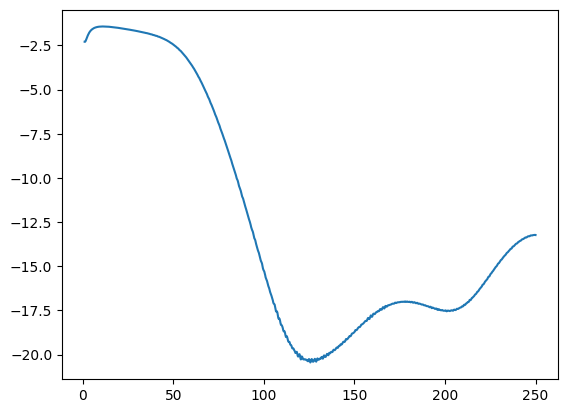

In [468]:
plt.figure()
plt.plot(rot_s11.freqs, lin2dB(rot_s11.s11_cal['ant']))
plt.show()

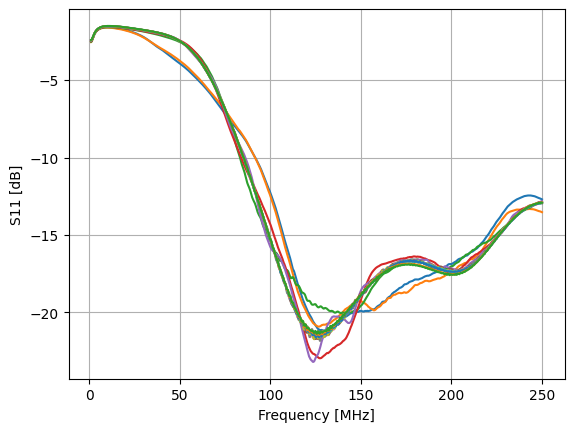

In [433]:
lift_s11 = s11[:13]

plt.figure()
for s in lift_s11:
    plt.plot(s.freqs, lin2dB(s.s11_cal["ant"]))
plt.xlabel("Frequency [MHz]")
plt.ylabel("S11 [dB]")
# plt.legend()
plt.grid()
plt.show()

In [473]:


# insertion positions in rot_s11.freqs
pos = np.searchsorted(rot_s11.freqs, rot_freq)

# clamp so we can safely check neighbors
pos = np.clip(pos, 1, len(rot_s11.freqs) - 1)

left = pos - 1
right = pos

# choose whichever neighbor is closer
idx = np.where(np.abs(rot_s11.freqs[left] - rot_freq) <= np.abs(rot_s11.freqs[right] - rot_freq), left, right)

print(idx)        # [0 2 4]
print(rot_s11.freqs[idx])   # [0.1 2.1 4.2]

[200 215 231 247 262 278 294 309 325 341 356 372 388 403 419 435 450 466
 482 497 513 529 545 560 576 592 607 623 639 654 670 686 701 717 733 748
 764 780 795 811 827 842 858 874 889 905 921 936 952 968 983]
[ 50.84984985  54.58858859  58.57657658  62.56456456  66.3033033
  70.29129129  74.27927928  78.01801802  82.00600601  85.99399399
  89.73273273  93.72072072  97.70870871 101.4474474  105.4354354
 109.4234234  113.1621622  117.1501502  121.1381381  124.8768769
 128.8648649  132.8528529  136.8408408  140.5795796  144.5675676
 148.5555556  152.2942943  156.2822823  160.2702703  164.009009
 167.996997   171.984985   175.7237237  179.7117117  183.6996997
 187.4384384  191.4264264  195.4144144  199.1531532  203.1411411
 207.1291291  210.8678679  214.8558559  218.8438438  222.5825826
 226.5705706  230.5585586  234.2972973  238.2852853  242.2732733
 246.012012  ]


In [478]:
rot_s11.freqs[idx].shape

(51,)

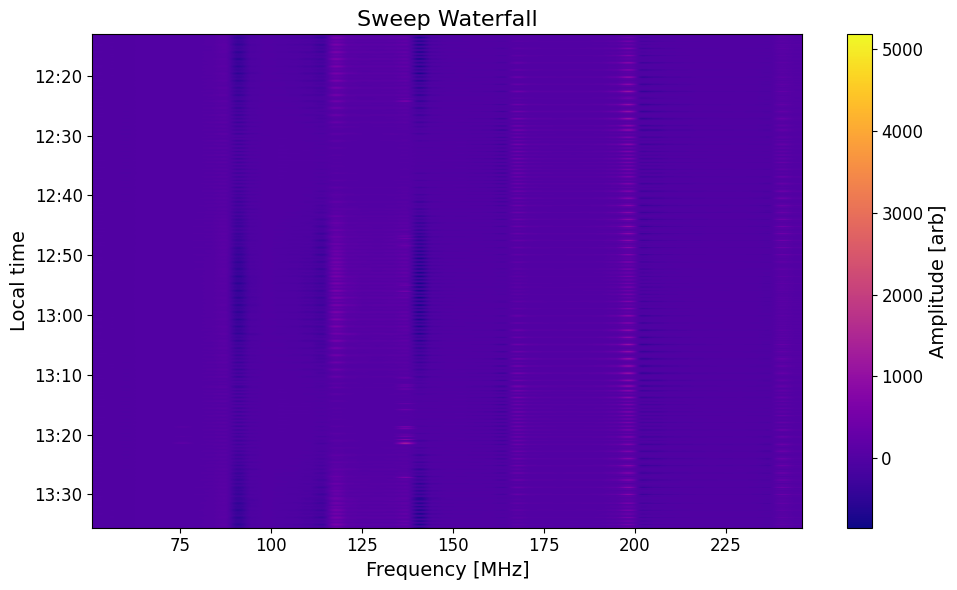

In [496]:
s11_factor = (1 - 10**((rot_s11.s11_cal['ant']/10))).imag
local_rot_times = [datetime.fromtimestamp(t) for t in rot_times]

rot_data = rot.real*norm
rot_data[np.where(rot_data<0)] = 0
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    rot_data / s11_factor[idx], 
    aspect='auto',
    origin='lower',
    extent=[rot_freq.min(), rot_freq.max(), mdates.date2num(local_rot_times[-1]), mdates.date2num(local_rot_times[0])],
    vmin=None, vmax=None, cmap='plasma'
)

ax.set_xlabel("Frequency [MHz]", fontsize=14)
ax.set_ylabel("Local time", fontsize=14)
ax.set_title("Sweep Waterfall", fontsize=16)
ax.tick_params(axis='both', labelsize=12)

# format the y-axis as dates/rot_times
ax.yaxis_date()
# ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# fig.colorbar(im, ax=ax, label="Power")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Amplitude [arb]", fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
# plt.savefig('/Users/dominiv/sfsu/thesis/figures/waterfall.pdf')
# plt.savefig('/Users/dominiv/sfsu/cose2026/figures/waterfall.pdf')
plt.show()

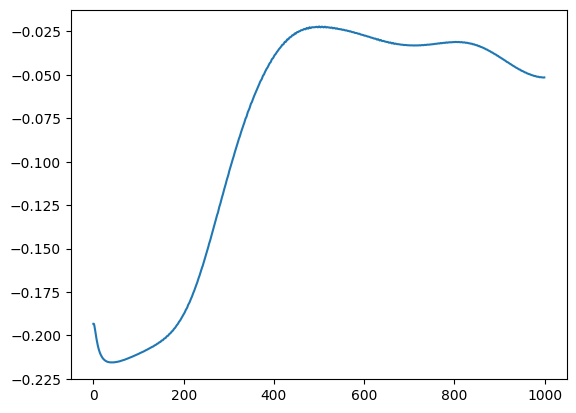

In [491]:
s11_factor = (1 - 10**(np.abs(rot_s11.s11_cal['ant']/10)))

plt.figure()
plt.plot(s11_factor)
# plt.plot(s11_factor.imag)
# plt.plot(s11_factor.real)
plt.show()